In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


Load Dataset

In [27]:
df = pd.read_csv("Mall_Customers.csv")

In [28]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


Check Missing Values

In [30]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Select Features

In [31]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_scaled

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

Elbow Method

In [34]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
  model = KMeans(n_clusters=i,random_state=42,n_init=10)
  model.fit(X_scaled)
  wcss.append(model.inertia_)



In [35]:
wcss

[600.0,
 389.3861889564371,
 295.2122461555488,
 205.22514747675922,
 168.24758017556837,
 133.86842085478852,
 117.01155455889811,
 103.87329152383714,
 93.09289110041726,
 82.38515364526597]

Plot

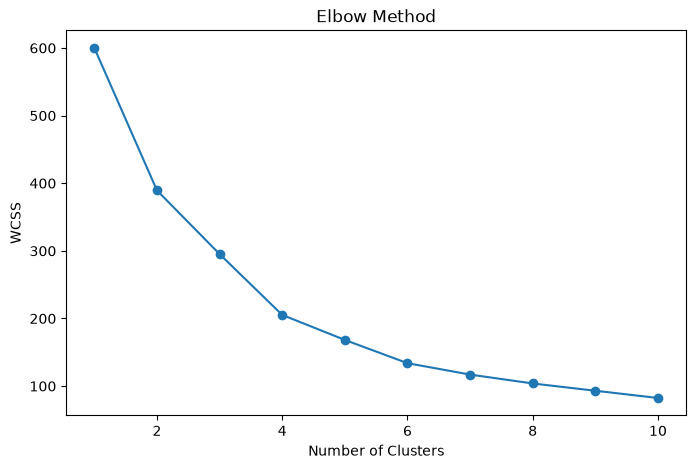

In [36]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

Apply K-Means

In [37]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [38]:
df['Cluster']

0      1
1      1
2      0
3      1
4      1
      ..
195    2
196    3
197    2
198    3
199    2
Name: Cluster, Length: 200, dtype: int32

Visualize Clusters

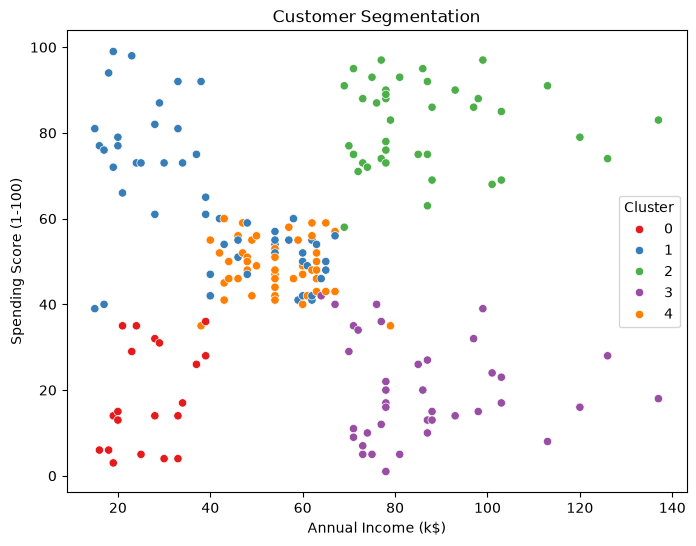

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1'
)

plt.title("Customer Segmentation")

plt.show()

Cluster Profiling

In [40]:
profile = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

print(profile)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


Save Cluster Labels

In [41]:
df.to_csv("clustered_customers.csv",index=False)